# Logistic Regression In-Class Exercises

Do these exercises along with the videos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Question 1.  Linear Classifier

Given the data below, use the `plt.scatter()` function to plot the data points with different colors for the classes.

Text(0, 0.5, 'x2')

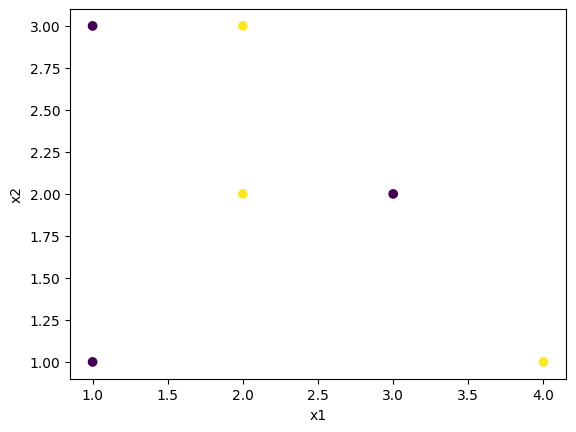

In [3]:
X = np.array([[1,1], [1,3], [2,2], [2,3], [3,2], [4,1]])
y = np.array([0,0,1,1,0,1], dtype=int)
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel('x1')
plt.ylabel('x2')
# TODO

You should see that the data is not linearly separable.
Find a linear classifier that makes a minimal number of errors on the training data.

Write a function `predict()` function for the classifer and get the predicted labels with the command:

    yhat = predict(X)

Print `yhat` and `y`.  How many errors does your classifier make?

In [9]:
def predict(X):
    # TODO
    #   yhat = ...
    x1 = X[:,0]
    x2 = X[:,1]
    z = x2 + 2*x1  -4
    yhat = (z>0).astype(int)
    return yhat

# TODO
#   yhat = predict(X)
yhat = predict(X)
acc = np.mean(yhat == y)
print('Accurancy = %4f' %acc)

Accurancy = 0.666667


# Question 2:   Logistic Model

Consider the model for the passing a test:

    P(pass test) = 1/(1+exp(-z)),  z =  w0 + w1*hrs_alone + w2*hrs_tutor
    
where `hrs_alone` is the number of hours studied alone and `hrs_tutor` is the number of hours with a tutor.
Given the values below find `w0` for the probability = 0.6.


In [11]:
hrs_alone = 4
hrs_tutor = 1
w1 = 0.2
w2 = 0.5
prob = 0.6

# TODO
#   w0 = ...
z = np.log(prob/(1-prob))
w0 = z-w1*hrs_alone - w2*hrs_tutor
print('w0 = %4f' %w0)

w0 = -0.894535


Given the values above, plot the probability of passing as a function of `hrs_tutor` in the range of 0 to 10 hours.

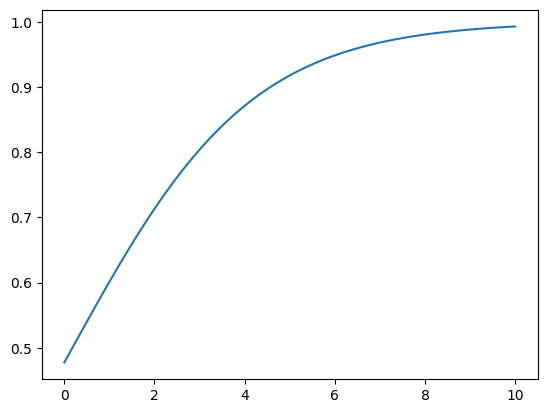

In [17]:
# TODO
w0 = -0.89
hrs_tutor = np.linspace( 0, 10, 100)
z = w0 + w1*hrs_alone + w2*hrs_tutor
prob = 1/(1+np.exp(-z))
plt.plot(hrs_tutor, prob)


## Question 3.  Calculating and Plotting the Binary Cross Entropy Loss

You are given the scalar data `x` and `y` with binary class labels below.

In [19]:
x = np.array([-1,1,3,4,5])
y = np.array([0,0,1,0,1])

Consider a linear classifier of the form:

    z = w[0] + w[1]*x
    yhat = 1 if z > 0 and 0 if z < 0
    
Find `w` that makes at most one error on the training data. Call this selection `w_manual` since you have manually chosen it.

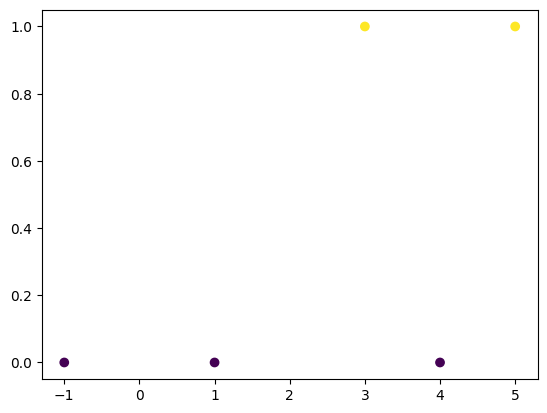

In [37]:
# TODO
#   w_manual = ...
plt.scatter(x,y,c=y.astype(int))
w = np.array([-2,0.8])

Now consider a logistic model,

    z = w[0] + w[1]*x
    p(y=1|x) = 1 / (1 + exp(-z))
    
Complete the function below that computes the binary cross entropy for a given vector `w` and training data `x,y`. Use the function to compute the BCE loss for the `w_manual`.

In [39]:
def bce_loss(x,y,w):
    # TODO
    z = w[0]+w[1]*x
    p = 1/(1+np.exp(-z))
    J = -np.mean(y*np.log(p)+(1-y)*np.log(1-p))
    return J
J = bce_loss(x,y,w)
print('the bce loss for w is %4f',J)
# Print the loss for `w_manual`

the bce loss for w is %4f 0.4851082048813919


Now consider a set of `w = [w0, 0.5]`.  
* Plot the BCE loss over 100 values `w0` from -2.5 to 0  
* What value of `w0`gives the minimum BCE loss?   Call this `w0_opt`.
* What is the minimum BCE loss?

min BCE loss: 0.478178. w0_opt = -1.742424


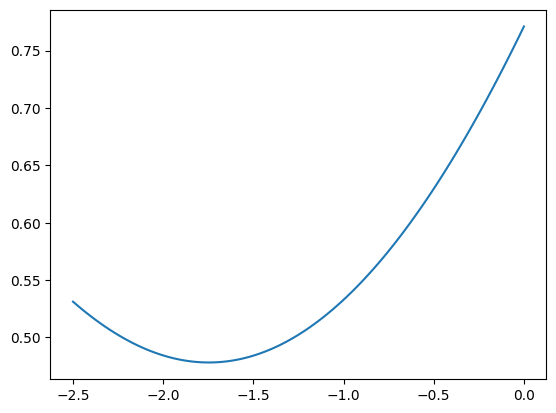

In [47]:
nt = 100
w0_test = np.linspace(-2.5,0,nt)
w = [w0_test, 0.5]
J = np.zeros(nt)
for i in range(nt):
  w = np.array([w0_test[i],0.5])
  J[i]= bce_loss(x,y,w)
plt.plot(w0_test,J)
# TODO
loss_opt = np.min(J)
w0_opt = w0_test[np.argmin(J)]
print('min BCE loss: %4f. w0_opt = %f' %(loss_opt,w0_opt))

Suppose you select `w1=0.5`and `w0=w0_opt` from the previous section.  What values `x` is `P(y=1|x) > 0.5`?

In [49]:
# TODO.  Describe the set

# We have P(y=1|x) > 0.5 <=> z > 0  <=> w0 + w1*x > 0 <=> x > t = -w0/w1
t = -w0_opt/w[1]
print('if x > %4f, the model predict y = 1' %t)

if x > 3.484848, the model predict y = 1


## Question 4.  Heart Attack Fit

In this exercise, we fit heart attack data from the UCI website.  We can load it as follows.

In [50]:
## Generate synthetic data
names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
         'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
df = pd.read_csv(url, na_values='?',header=None, names=names)
df = df.dropna()

Print the first few rows of the data frame.
Print the number of attributes of number of samples

In [57]:
# TODO
print(df.head())
nsample, nattributes = df.shape
print(f'the number of sample is {nsample}, the number of attributes is {nattributes}')

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  num  
0    3.0  0.0   6.0    0  
1    2.0  3.0   3.0    2  
2    2.0  2.0   7.0    1  
3    3.0  0.0   3.0    0  
4    1.0  0.0   3.0    0  
the number of sample is 297, the number of attributes is 14


The target will be `num` which is the number of arterial blockages.  Get the target vector `y` from the `df[num]` column.  To make this a binary classification problem, let `y[i] == 1` whenever the number is greater than 0.  Otherwise, `y[i] == 0`.  You will have to convert the value to integer.

In [61]:
# TODO
y = (df['num']>0).astype(int)

Get the data matrix `X` from all the attributes other than `num`.  

In [65]:
# TODO
#  X = ...
X = df.drop('num',axis = 1)

Split the data into traing and test with `test_size=0.25`.

In [67]:
from sklearn.model_selection import train_test_split

# TODO:
Xtr, Xts, ytr, yts = train_test_split(X,y,test_size=0.3)

Scale the training and test data with the `StandardScaler`.

In [72]:
from sklearn.preprocessing import StandardScaler

# TODO
#  Xtr1 = ...
#  Xts1 = ...
scaler = StandardScaler()
Xtr1 = scaler.fit_transform(Xtr)
Xts1 = scaler.transform(Xts)


Fit the data on the training data set, predict on the test and measure the accuracy.

In [78]:
# TODO
from sklearn import linear_model

reg = linear_model.LogisticRegression(C=1e5)
reg.fit(Xtr1,ytr)

yhat = reg.predict(Xts1)
acc = np.mean(yts == yhat)
print(f'the accurancy of the predict is {acc}')

the accurancy of the predict is 0.8777777777777778


Create a stem plot of the coefficients.  

In [ ]:
# TODO

## Further exercises

If you want to try a little more, see if you can use L1 regularization to find the features that are best in explaining heart blockages.